# Daily session ROI SNR summary

This notebook creates a compact day-level table of ROI statistics without saving individual ROI dF/F recordings. The saved stats are intended to support later metric-disagreement review, arbitrary grouping by day/session/plane/structure, and on-demand retrieval of a specific ROI trace using the saved `session_source`, `plane`, and `roi_index`.


In [1]:
from __future__ import annotations

import importlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

import sys
sys.path.insert(0, str(REPO_ROOT / "src"))

import mesoscope_qc_reports as qcr
import mesoscope_daily_snr as daily_snr

daily_snr = importlib.reload(daily_snr)

%matplotlib inline
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)


## Configuration

By default this uses the day from `qcr.DEFAULT_SESSION_SOURCE` and discovers local NWB files in the scratch DANDI download directory whose filename contains that date. To scale to all sessions from a day, add session sources directly or provide a text manifest to the script `scripts/generate_daily_snr_summary.py`.


In [2]:
DEFAULT_DAY = "2026-02-20"
DAY = DEFAULT_DAY

SESSION_SOURCES = None  # None means discover local *DAY*.nwb files in SEARCH_DIRS.
SEARCH_DIRS = [daily_snr.DEFAULT_DOWNLOAD_DIR]
OUTPUT_ROOT = REPO_ROOT / "outputs" / "snr_metrics_by_day"

CONFIG = daily_snr.SnrBatchConfig(
    day=DAY,
    planes="all",
    max_frames=None,
    gaussian_sigma=3.0,
    consecutive_samples=5,
    event_threshold=0.0,
    baseline_bins=10,
    kernel_pre_s=0.5,
    kernel_post_s=2.0,
    max_kernel_events=500,
    min_events_for_distribution_fit=20,
)

# Trace-grid summary settings. These retrieve traces on demand; traces are not saved.
N_RANDOM_TRACES_PER_BIN = 20
N_AVERAGE_TRACES_PER_BIN = 60   # cap for the average row; raise for smoother averages if runtime is acceptable
BIN_TRACE_WINDOW_S = 180        # seconds from session start shown in trace grids
TRACE_RANDOM_SEED = 7

print("Day:", DAY)
print("Search dirs:", SEARCH_DIRS)
print("Discovered local sessions:")
for source in daily_snr.discover_local_sessions_for_day(DAY, SEARCH_DIRS):
    print(" ", source)


Day: 2026-02-20
Search dirs: [PosixPath('/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads')]
Discovered local sessions:
  /storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-53-27_ophys.nwb


## Run and save compact day-level stats

Outputs are written under `outputs/snr_metrics_by_day/<day>/`:

- `roi_metrics.csv`: one row per ROI, including all SNR/event metrics and identifiers needed to retrieve the trace later.
- `plane_inventory.csv`: one row per session/plane with ROI count, timepoints, duration, and event availability.
- `session_inventory.csv`: one row per session.
- `timing.csv`: elapsed time for each plane and session total.
- `storage_usage.csv`: output file sizes.
- `manifest.json`: run configuration, elapsed time, output paths, and total output size.


In [3]:
result = daily_snr.run_daily_summary(
    DAY,
    session_sources=SESSION_SOURCES,
    search_dirs=SEARCH_DIRS,
    output_root=OUTPUT_ROOT,
    config=CONFIG,
)

manifest = result["manifest"]
print(json.dumps(manifest, indent=2))


{
  "day": "2026-02-20",
  "session_sources": [
    "/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-53-27_ophys.nwb"
  ],
  "config": {
    "day": "2026-02-20",
    "planes": "all",
    "max_frames": null,
    "gaussian_sigma": 3.0,
    "consecutive_samples": 5,
    "exceptional_robust_std": false,
    "event_threshold": 0.0,
    "baseline_bins": 10,
    "kernel_pre_s": 0.5,
    "kernel_post_s": 2.0,
    "max_kernel_events": 500,
    "min_events_for_distribution_fit": 20
  },
  "elapsed_s": 42.91479316400364,
  "n_sessions": 1,
  "n_planes": 8,
  "n_roi_rows": 1810,
  "output_dir": "/storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/snr_metrics_by_day/2026-02-20",
  "total_output_size_bytes": 1530229,
  "total_output_size_mb": 1.4593400955200195,
  "artifacts": {
    "roi_metrics": "/storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/snr_metrics_by_day/2026-02-20/roi_metrics.csv",
    "plane_inventory": "

In [4]:
roi_metrics = result["roi_metrics"]
plane_inventory = result["plane_inventory"]
session_inventory = result["session_inventory"]
timing = result["timing"]
storage_usage = result["storage_usage"]

print("ROI rows:", len(roi_metrics))
display(session_inventory)
display(plane_inventory)
display(timing)
display(storage_usage)


ROI rows: 1810


,session_source,session_id,session_date,n_planes,n_rois,n_timepoints_min,n_timepoints_max,duration_s_max,has_events_all
0,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,8,1810,46303,46303,4325.61564,True


,session_source,session_id,session_date,plane,n_rois,n_timepoints,duration_s,has_events
0,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISl_4,351,46303,4325.61563,True
1,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISl_5,235,46303,4325.61563,True
2,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISl_6,76,46303,4325.61564,True
3,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISl_7,288,46303,4325.61564,True
4,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISp_0,345,46303,4325.61563,True
5,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISp_1,230,46303,4325.61563,True
6,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISp_2,84,46303,4325.61564,True
7,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISp_3,201,46303,4325.61564,True


,session_id,plane,status,elapsed_s,n_rois,n_timepoints
0,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_4,ok,6.864865,351,46303.0
1,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_5,ok,6.635263,235,46303.0
2,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_6,ok,1.609603,76,46303.0
3,multiplane-ophys_839909_2026-02-20_12-53-27,VISl_7,ok,7.675385,288,46303.0
4,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_0,ok,6.809522,345,46303.0
5,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_1,ok,6.384418,230,46303.0
6,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_2,ok,1.865323,84,46303.0
7,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_3,ok,3.652618,201,46303.0
8,multiplane-ophys_839909_2026-02-20_12-53-27,__session_total__,ok,42.797238,1810,NaN


,path,size_bytes,size_mb
0,/storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/snr_metrics_by_day/2026-02-20/manifest.json,1498,0.001429
1,/storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/snr_metrics_by_day/2026-02-20/plane_inventory.csv,1845,0.001760
2,/storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/snr_metrics_by_day/2026-02-20/roi_metrics.csv,1524918,1.454275
3,/storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/snr_metrics_by_day/2026-02-20/session_inventory.csv,341,0.000325
4,/storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/snr_metrics_by_day/2026-02-20/storage_usage.csv,811,0.000773
5,/storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/snr_metrics_by_day/2026-02-20/timing.csv,814,0.000776


## Distribution plots

These compact tables can be grouped arbitrarily after the run. The examples below group by plane, but the same table supports `session_id`, `session_date`, `structure`, or custom labels added later.


/storage/home/hcoda1/3/grubin6/scratch/tmp/ipykernel_3396302/1638560470.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(groups, labels=labels, showfliers=False)


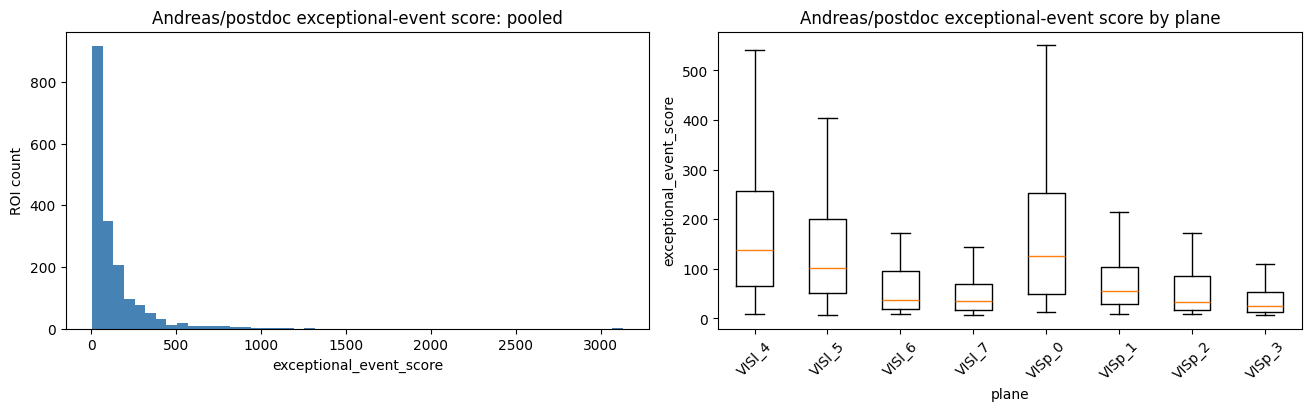

/storage/home/hcoda1/3/grubin6/scratch/tmp/ipykernel_3396302/1638560470.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(groups, labels=labels, showfliers=False)


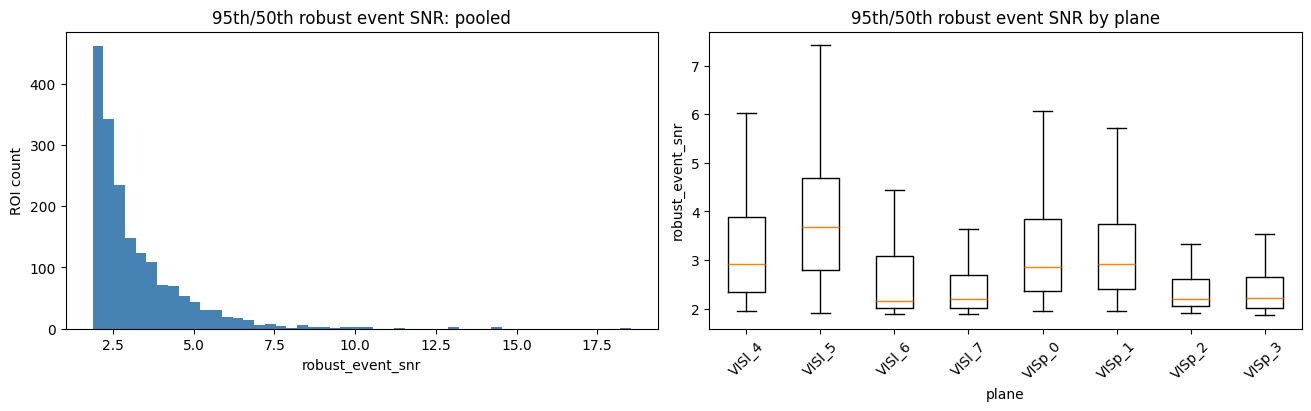

/storage/home/hcoda1/3/grubin6/scratch/tmp/ipykernel_3396302/1638560470.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(groups, labels=labels, showfliers=False)


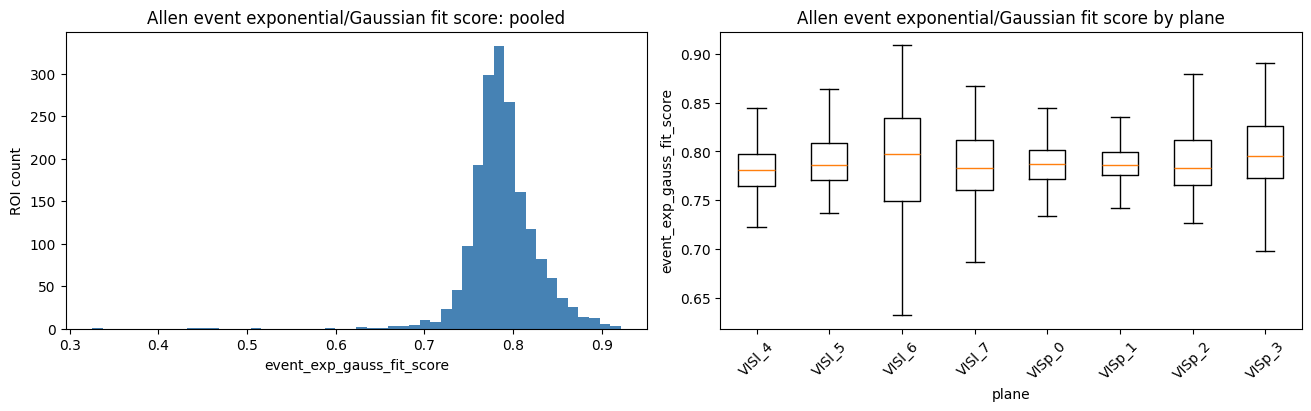

/storage/home/hcoda1/3/grubin6/scratch/tmp/ipykernel_3396302/1638560470.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(groups, labels=labels, showfliers=False)


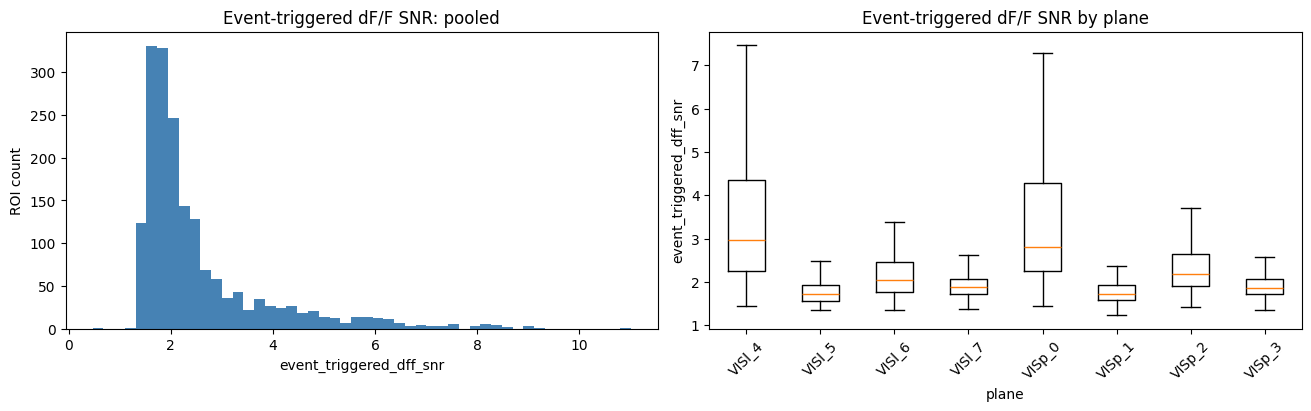

In [5]:
METRICS_TO_PLOT = {
    "Sustained exceptional-event score": "exceptional_event_score",
    "95th/50th robust event SNR": "robust_event_snr",
    "Allen event exponential/Gaussian fit score": "event_exp_gauss_fit_score",
    "Event-triggered dF/F SNR": "event_triggered_dff_snr",
}
GROUP_BY = "plane"

for label, metric in METRICS_TO_PLOT.items():
    plot_df = roi_metrics[[GROUP_BY, metric]].dropna().copy()
    if plot_df.empty:
        print("No finite values for", metric)
        continue
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
    axes[0].hist(plot_df[metric], bins=50, color="steelblue")
    axes[0].set(title=f"{label}: pooled", xlabel=metric, ylabel="ROI count")
    groups = [g[metric].to_numpy() for _, g in plot_df.groupby(GROUP_BY, dropna=False)]
    labels = [str(name) for name, _ in plot_df.groupby(GROUP_BY, dropna=False)]
    axes[1].boxplot(groups, labels=labels, showfliers=False)
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].set(title=f"{label} by {GROUP_BY}", xlabel=GROUP_BY, ylabel=metric)
    plt.show()


## Metric disagreement examples

The saved ROI metrics can be sorted after the run to find cases where metrics disagree. These rows include `session_source`, `session_id`, `plane`, and `roi_index`, which are the identifiers needed to retrieve the full trace later.


In [6]:
def find_metric_disagreements(df, high_metric, low_metric, *, high_q=0.8, low_q=0.2, n=10):
    cols = ["session_source", "session_id", "session_date", "plane", "roi_index", high_metric, low_metric]
    work = df[cols].copy()
    work[high_metric] = pd.to_numeric(work[high_metric], errors="coerce")
    work[low_metric] = pd.to_numeric(work[low_metric], errors="coerce")
    work = work.dropna(subset=[high_metric, low_metric])
    hi = work[high_metric].quantile(high_q)
    lo = work[low_metric].quantile(low_q)
    out = work.loc[(work[high_metric] >= hi) & (work[low_metric] <= lo)].copy()
    out["disagreement_rank"] = out[high_metric].rank(ascending=False) + out[low_metric].rank(ascending=True)
    return out.sort_values("disagreement_rank").head(n)

examples = {
    "high_exceptional_low_95_50": find_metric_disagreements(roi_metrics, "exceptional_event_score", "robust_event_snr"),
    "high_95_50_low_exceptional": find_metric_disagreements(roi_metrics, "robust_event_snr", "exceptional_event_score"),
    "high_95_50_low_event_fit": find_metric_disagreements(roi_metrics, "robust_event_snr", "event_exp_gauss_fit_score"),
}
for name, table in examples.items():
    print("\n" + name)
    display(table)



high_exceptional_low_95_50


,session_source,session_id,session_date,plane,roi_index,exceptional_event_score,robust_event_snr,disagreement_rank
1089,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISp_0,139,397.555349,2.074955,2.0



high_95_50_low_exceptional


,session_source,session_id,session_date,plane,roi_index,robust_event_snr,exceptional_event_score,disagreement_rank



high_95_50_low_event_fit


,session_source,session_id,session_date,plane,roi_index,robust_event_snr,event_exp_gauss_fit_score,disagreement_rank
284,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISl_4,284,6.359288,0.695287,13.0
1311,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISp_1,16,8.715221,0.741527,15.0
433,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISl_5,82,10.510604,0.747657,16.0
189,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISl_4,189,5.644144,0.703558,18.0
529,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISl_5,178,5.824192,0.710225,18.0
952,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISp_0,2,6.105272,0.734707,20.0
958,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISp_0,8,6.248874,0.740423,21.0
56,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISl_4,56,5.609270,0.741382,26.0
515,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISl_5,164,5.216218,0.736474,27.0
419,/storage/scratch1/3/grubin6/openscope_ophys_qc_dandi_downloads/sub-839909_ses-multiplane-ophys-839909-2026-02-20-12-...,multiplane-ophys_839909_2026-02-20_12-53-27,2026-02-20,VISl_5,68,13.124615,0.757601,27.0


## Low / medium / high metric-bin trace summaries

For each metric, ROIs are split into three equal-count bins: low, medium, and high metric values. Each plot has three columns, one for each bin. The first row shows the average trace for sampled ROIs in that bin, and the remaining rows show randomly selected single-ROI traces from the same bin.

This view is intended to make it obvious what a metric is selecting for: e.g., whether high values correspond to visibly cleaner calcium traces, stronger transients, more event-like structure, or potential artifacts.


In [7]:
def assign_metric_bins(df, metric):
    """Assign low/mid/high labels by metric tertiles."""
    work = df.copy()
    values = pd.to_numeric(work[metric], errors="coerce")
    work = work.loc[values.notna()].copy()
    work[metric] = values[values.notna()]
    if work.empty:
        work["metric_bin"] = pd.Series(dtype=object)
        return work
    ranks = work[metric].rank(method="first")
    try:
        work["metric_bin"] = pd.qcut(ranks, q=3, labels=["low", "medium", "high"])
    except ValueError:
        work["metric_bin"] = "medium"
    return work


def select_bin_rois(df, metric, n_random=N_RANDOM_TRACES_PER_BIN, n_average=N_AVERAGE_TRACES_PER_BIN, seed=TRACE_RANDOM_SEED):
    """Select per-bin ROIs for plotting and average traces."""
    binned = assign_metric_bins(df, metric)
    selections = {}
    rng = np.random.default_rng(seed)
    for bin_name in ["low", "medium", "high"]:
        bin_df = binned.loc[binned["metric_bin"].astype(str) == bin_name].copy()
        if bin_df.empty:
            selections[bin_name] = {"plot": bin_df, "average": bin_df}
            continue
        plot_n = min(n_random, len(bin_df))
        avg_n = min(max(n_average, plot_n), len(bin_df))
        plot_idx = rng.choice(bin_df.index.to_numpy(), size=plot_n, replace=False)
        avg_idx = rng.choice(bin_df.index.to_numpy(), size=avg_n, replace=False)
        selections[bin_name] = {
            "plot": bin_df.loc[plot_idx].sort_values(metric),
            "average": bin_df.loc[avg_idx],
        }
    return selections


def _load_selected_traces(selection_df, trace_window_s=BIN_TRACE_WINDOW_S):
    """Load selected dF/F traces grouped by session/plane, reading only selected ROI columns."""
    traces = {}
    if selection_df.empty:
        return traces
    group_cols = ["session_source", "session_id", "plane"]
    for (session_source, session_id, plane), group in selection_df.groupby(group_cols, dropna=False):
        session = qcr.open_session(session_source)
        try:
            nwb = session["nwb"]
            proc = nwb.processing[str(plane)]
            dff_series = daily_snr.qc.get_timeseries_from_proc(
                proc,
                [("dff_timeseries", "dff_timeseries"), ("dff_timeseries",)],
            )
            if dff_series is None:
                continue
            timestamps_all = np.asarray(dff_series.timestamps[:], dtype=float)
            if trace_window_s is None:
                stop = len(timestamps_all)
            else:
                stop = int(np.searchsorted(timestamps_all, timestamps_all[0] + trace_window_s, side="right"))
                stop = max(2, min(stop, len(timestamps_all)))
            timestamps = timestamps_all[:stop]
            roi_indices = sorted(set(int(i) for i in group["roi_index"]))
            # h5py fancy indexing requires increasing unique column indices.
            data = np.asarray(dff_series.data[:stop, roi_indices], dtype=np.float32)
            for col, roi_index in enumerate(roi_indices):
                traces[(str(session_id), str(plane), int(roi_index))] = {
                    "timestamps": timestamps,
                    "dff": data[:, col],
                }
        finally:
            qcr.close_session(session)
    return traces


def _common_time_average(trace_records):
    """Interpolate traces onto a common relative-time axis and return mean trace."""
    valid = [record for record in trace_records if record is not None and len(record["dff"]) > 1]
    if not valid:
        return None, None
    min_end = min(float(record["timestamps"][-1] - record["timestamps"][0]) for record in valid)
    dt = np.nanmedian([np.nanmedian(np.diff(record["timestamps"])) for record in valid])
    common_t = np.arange(0, min_end + 0.5 * dt, dt)
    aligned = []
    for record in valid:
        t = record["timestamps"] - record["timestamps"][0]
        trace = record["dff"]
        interp = np.interp(common_t, t, trace)
        interp = interp - np.nanmedian(interp[: max(2, min(20, len(interp)))])
        aligned.append(interp)
    return common_t, np.nanmean(np.vstack(aligned), axis=0)


def plot_metric_trace_bins(df, metric, label, n_random=N_RANDOM_TRACES_PER_BIN, n_average=N_AVERAGE_TRACES_PER_BIN):
    selections = select_bin_rois(df, metric, n_random=n_random, n_average=n_average)
    selected_rows = []
    for selected in selections.values():
        selected_rows.append(selected["plot"])
        selected_rows.append(selected["average"])
    selected_df = pd.concat(selected_rows, ignore_index=False).drop_duplicates(
        subset=["session_id", "plane", "roi_index"]
    )
    traces = _load_selected_traces(selected_df)

    n_rows = n_random + 1
    fig, axes = plt.subplots(
        n_rows,
        3,
        figsize=(13, max(8, 0.55 * n_rows)),
        sharex=True,
        constrained_layout=True,
    )
    bin_names = ["low", "medium", "high"]
    for col, bin_name in enumerate(bin_names):
        plot_rows = selections[bin_name]["plot"]
        avg_rows = selections[bin_name]["average"]
        metric_values = pd.to_numeric(avg_rows[metric], errors="coerce") if not avg_rows.empty else pd.Series(dtype=float)
        title = f"{bin_name}\nn={len(assign_metric_bins(df, metric).query('metric_bin == @bin_name'))}"
        if len(metric_values):
            title += f"\nmedian={metric_values.median():.3g}"
        axes[0, col].set_title(title)

        avg_records = [
            traces.get((str(row.session_id), str(row.plane), int(row.roi_index)))
            for _, row in avg_rows.iterrows()
        ]
        avg_t, avg_trace = _common_time_average(avg_records)
        if avg_t is not None:
            axes[0, col].plot(avg_t, avg_trace, color="black", lw=1.2)
        axes[0, col].set_ylabel("average")

        for row_i in range(n_random):
            ax = axes[row_i + 1, col]
            if row_i >= len(plot_rows):
                ax.axis("off")
                continue
            row = plot_rows.iloc[row_i]
            record = traces.get((str(row.session_id), str(row.plane), int(row.roi_index)))
            if record is None:
                ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes)
                continue
            t = record["timestamps"] - record["timestamps"][0]
            trace = record["dff"]
            trace = trace - np.nanmedian(trace[: max(2, min(20, len(trace)))])
            ax.plot(t, trace, color="0.2", lw=0.55)
            ax.set_ylabel(f"ROI {int(row.roi_index)}", fontsize=7)
            ax.tick_params(axis="y", labelsize=6)
        axes[-1, col].set_xlabel("time from session start (s)")

    fig.suptitle(f"{label}: low / medium / high metric bins", fontweight="bold")
    plt.show()
    return selections


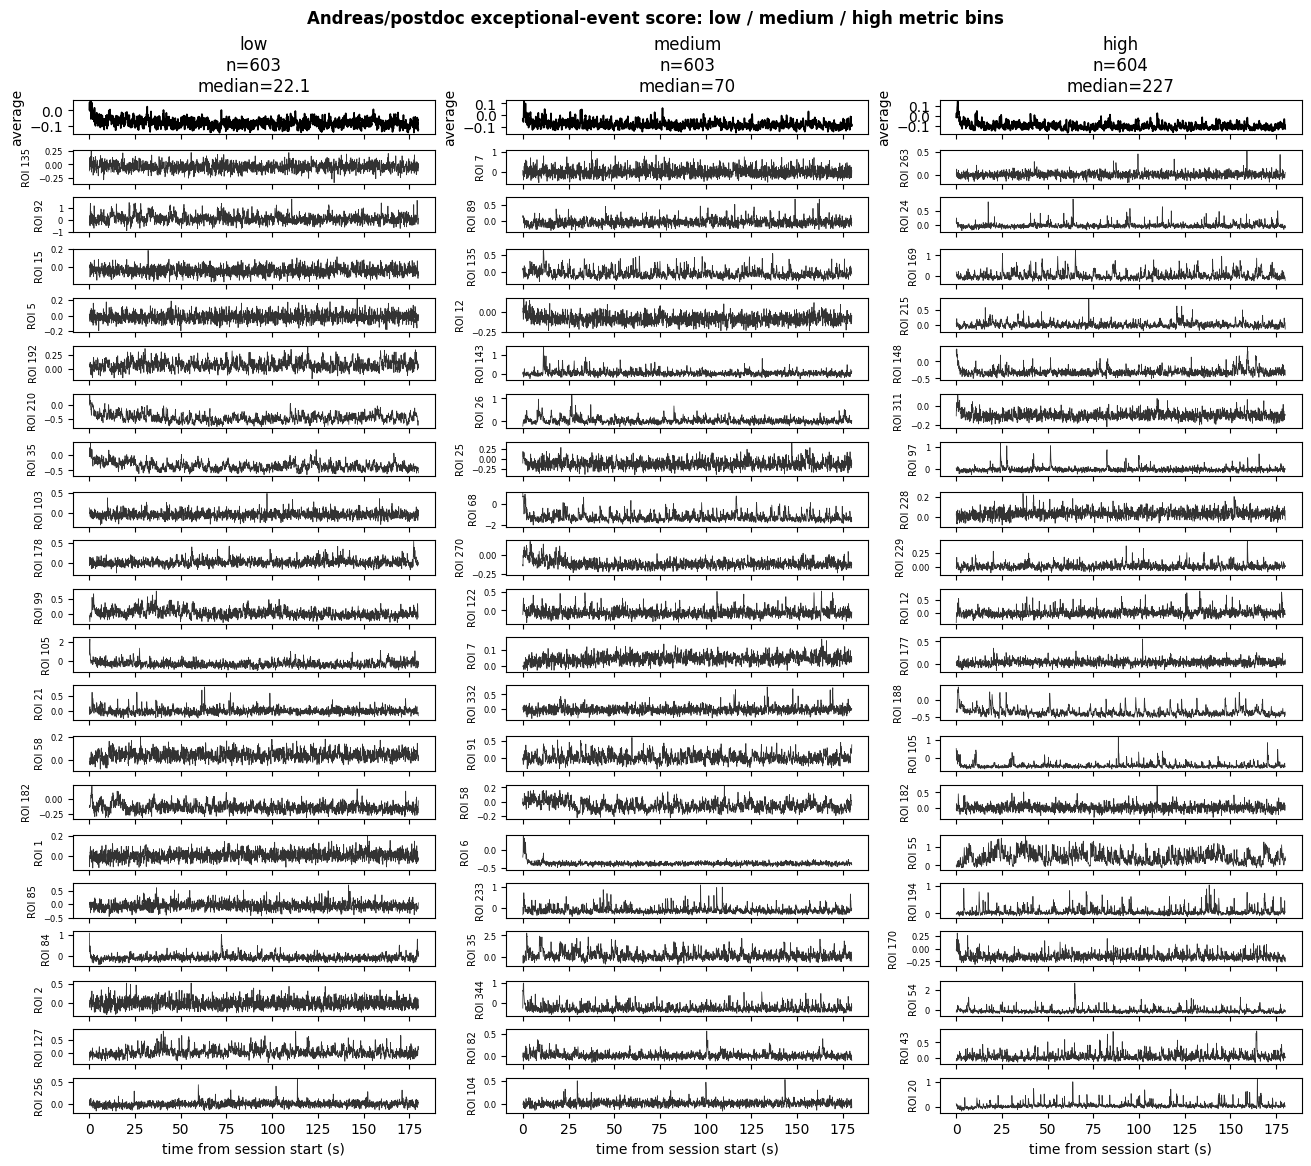

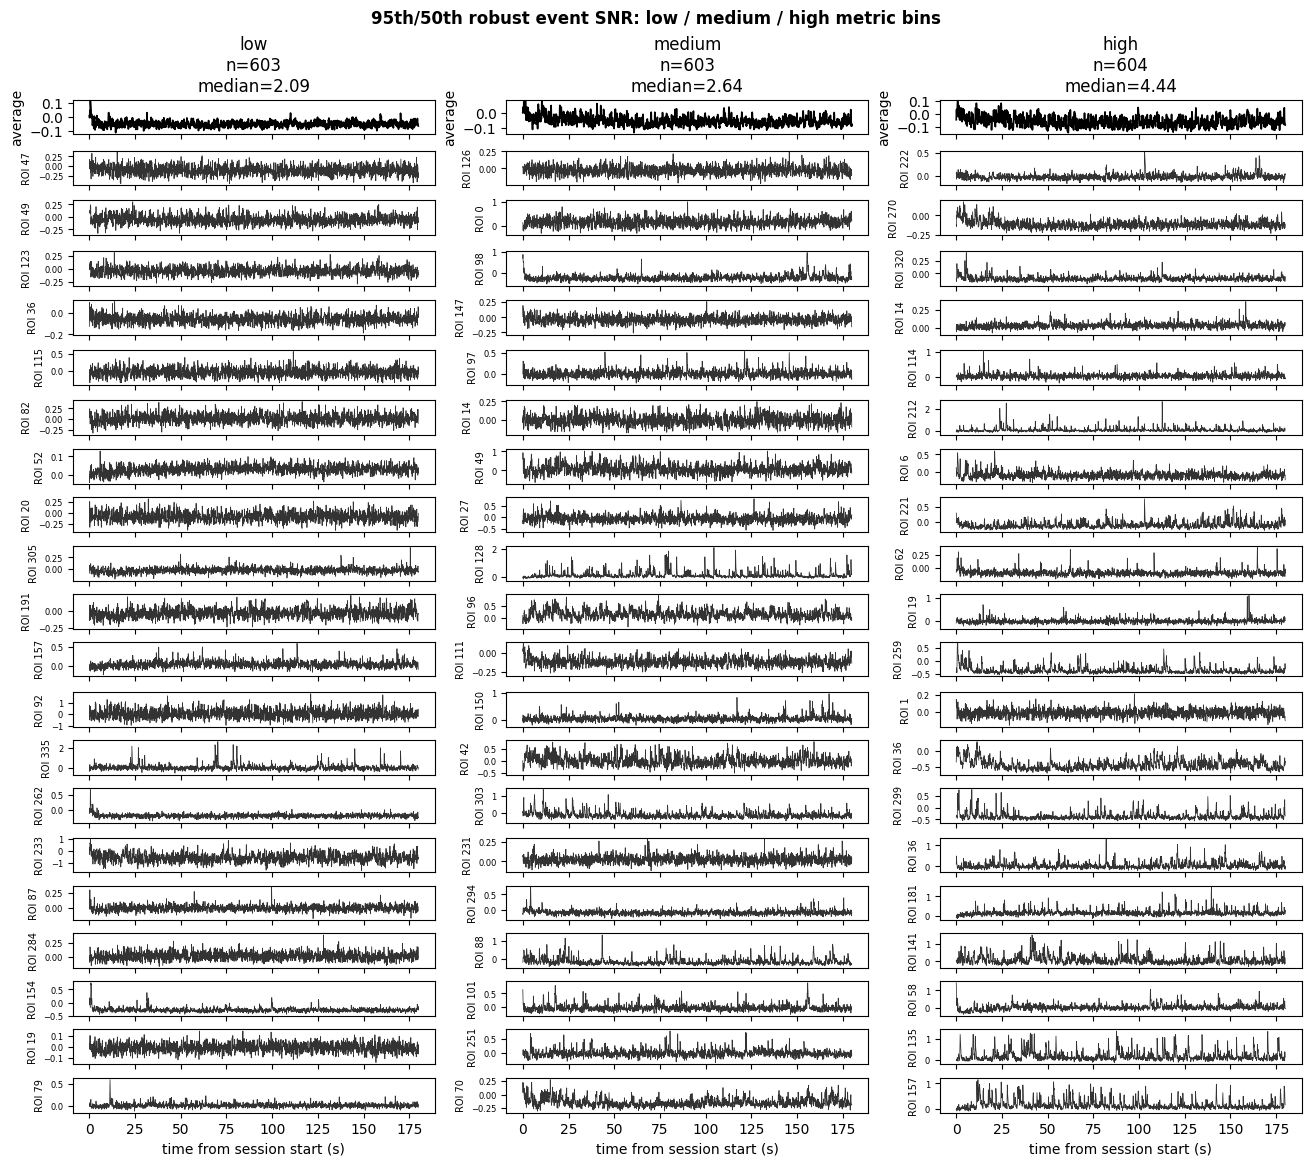

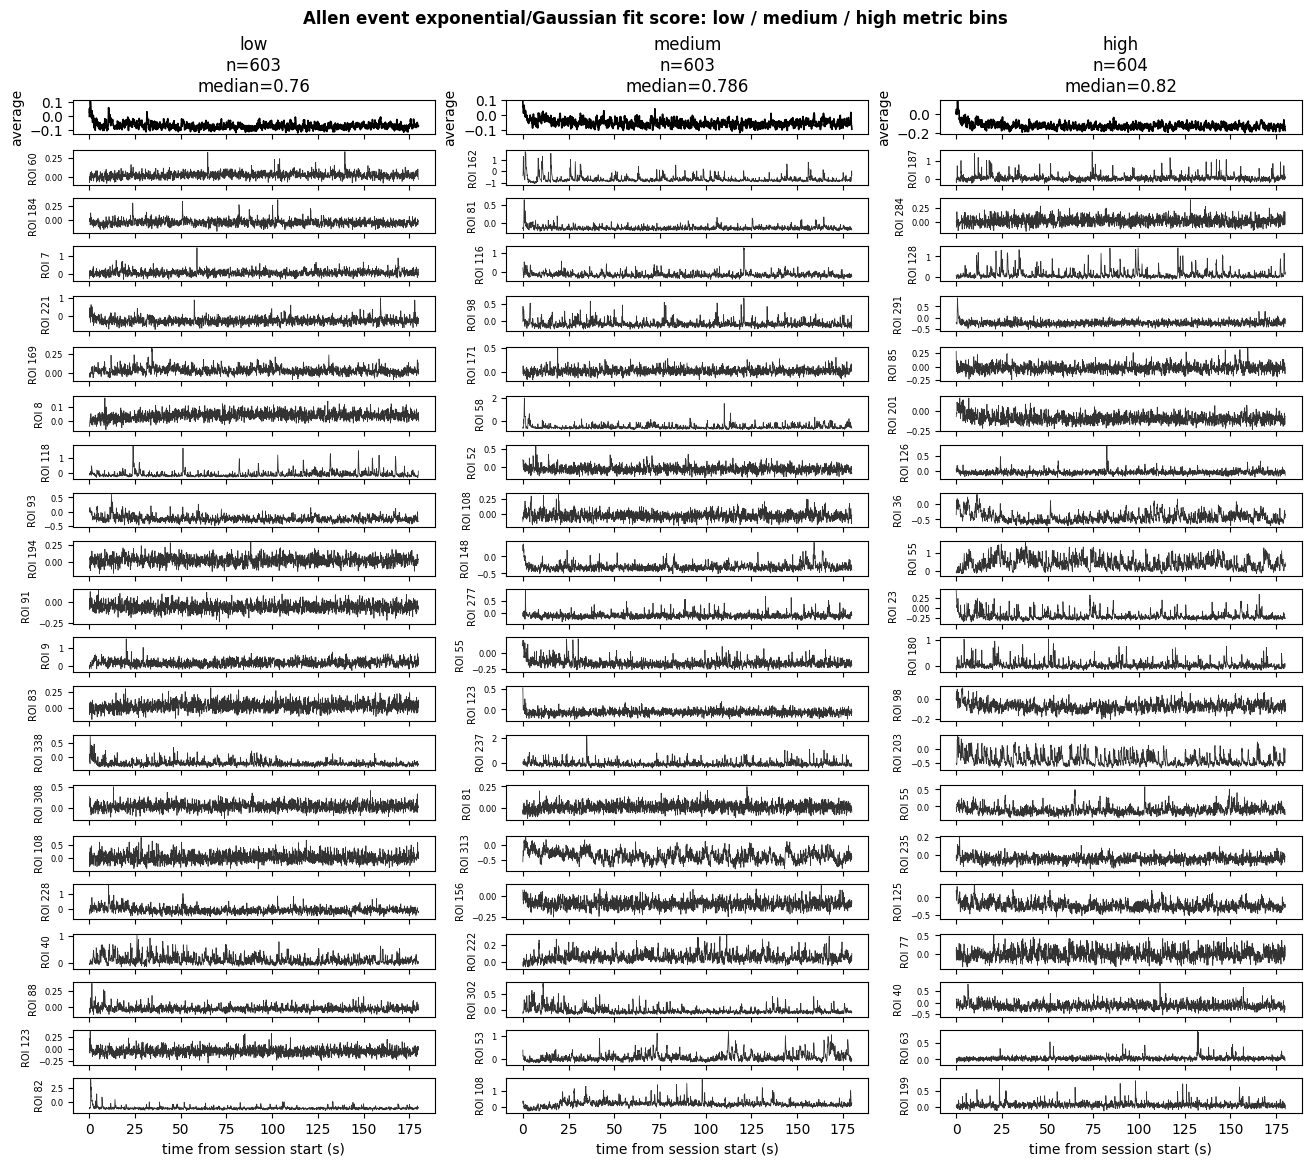

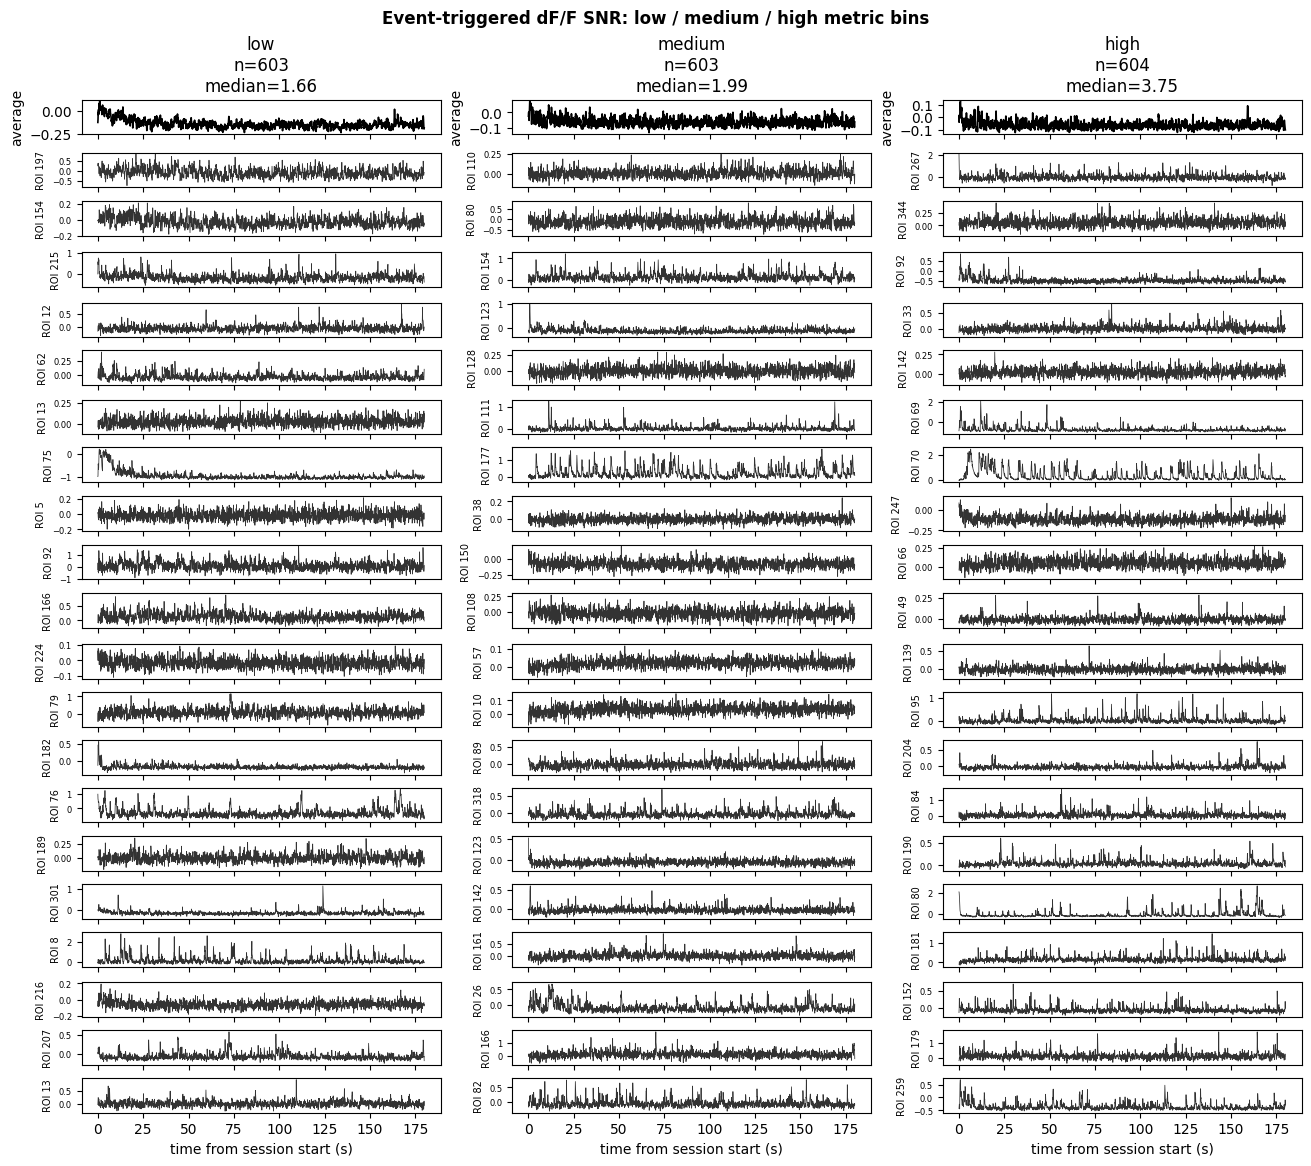

In [8]:
BIN_TRACE_SELECTIONS = {}
for label, metric in METRICS_TO_PLOT.items():
    if metric not in roi_metrics:
        print(f"Skipping missing metric: {metric}")
        continue
    BIN_TRACE_SELECTIONS[metric] = plot_metric_trace_bins(roi_metrics, metric, label)


## On-demand ROI trace retrieval

The summary does not save full dF/F traces. When a row looks interesting, use the saved identifiers to retrieve only that ROI's dF/F and optional event trace from the source NWB.


multiplane-ophys_839909_2026-02-20_12-53-27 VISp_0 139 (46303,)


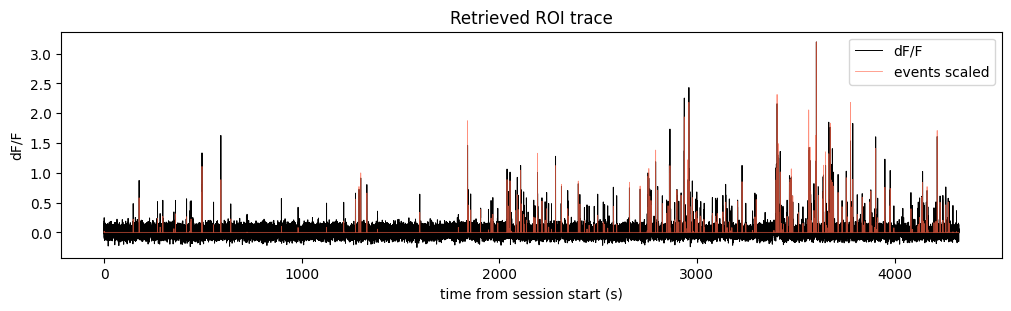

In [9]:
roi_metrics_path = Path(manifest["artifacts"]["roi_metrics"])
example_source = next((table for table in examples.values() if not table.empty), None)
if example_source is None:
    example_row = roi_metrics.sort_values("robust_event_snr", ascending=False).iloc[0]
else:
    example_row = example_source.iloc[0]

trace = daily_snr.retrieve_roi_trace_from_stats(
    roi_metrics_path,
    session_id=example_row["session_id"],
    plane=example_row["plane"],
    roi_index=int(example_row["roi_index"]),
    max_frames=None,
    include_events=True,
)

print(trace["session_id"], trace["plane"], trace["roi_index"], trace["dff"].shape)
fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)
t = trace["timestamps"] - trace["timestamps"][0]
ax.plot(t, trace["dff"], lw=0.7, color="black", label="dF/F")
if trace["events"] is not None and trace["events"].max() > 0:
    scaled_events = trace["events"] / trace["events"].max() * max(trace["dff"].max(), 1e-9)
    ax.plot(t, scaled_events, lw=0.6, color="tomato", alpha=0.7, label="events scaled")
ax.set(xlabel="time from session start (s)", ylabel="dF/F", title="Retrieved ROI trace")
ax.legend(loc="upper right")
plt.show()
